In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.insert(0, '/content/drive/MyDrive/CSE720/code')
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from config import Config
from dataset import MedicalDataset
from model import Generator
cfg = Config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Mounted at /content/drive


                                              psnr            ssim          \
                                              mean     std    mean     std   
source               target                                                  
Diabetic_Retinopathy Glaucoma              35.1592  2.5480  0.9002  0.0260   
                     Healthy               35.9697  3.4071  0.9084  0.0491   
                     Macular_Scar          36.7172  3.2009  0.9272  0.0353   
                     Myopia                35.7802  2.7662  0.9142  0.0257   
Glaucoma             Diabetic_Retinopathy  35.6593  2.1969  0.9160  0.0212   
                     Healthy               38.5430  2.2909  0.9508  0.0335   
                     Macular_Scar          38.8718  1.7180  0.9577  0.0184   
                     Myopia                35.6394  2.0646  0.9184  0.0245   
Healthy              Diabetic_Retinopathy  35.9163  1.7221  0.9253  0.0176   
                     Glaucoma              36.4348  1.6390  0.93

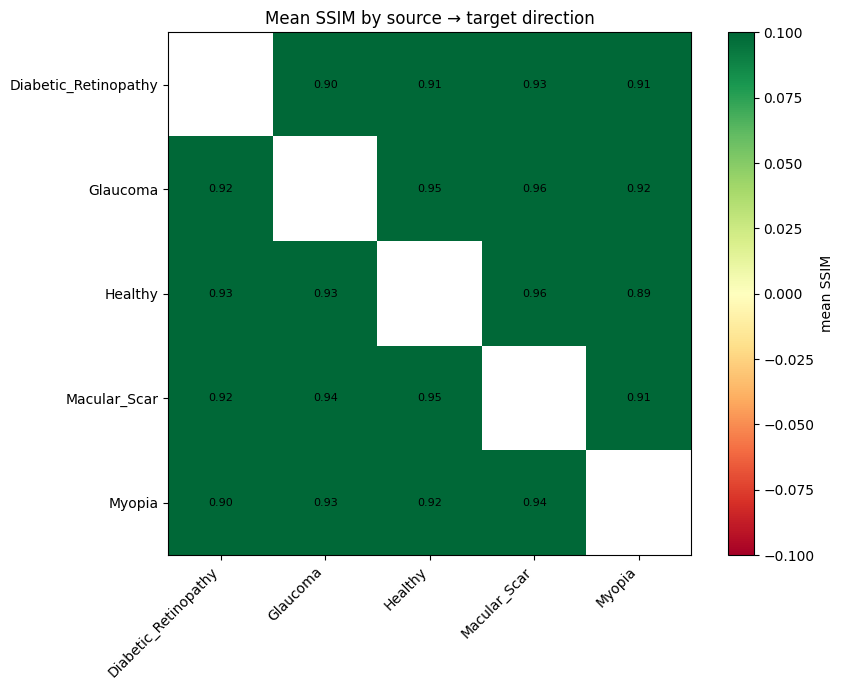

In [ ]:
df = pd.read_csv(os.path.join(cfg.eval_dir, 'EyeGAN_per_item_results.csv'))
direction_stats = df.groupby(['source', 'target'])[['psnr', 'ssim', 'mse']].agg(['mean', 'std']).round(4)
print(direction_stats)
direction_stats.to_csv(os.path.join(cfg.eval_dir, 'per_direction_error_stats.csv'))

fig, ax = plt.subplots(figsize=(9, 7))
pivot = df.pivot_table(index='source', columns='target', values='ssim', aggfunc='mean')
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=pivot.values.min(), vmax=1.0)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, label='mean SSIM')
plt.title('Mean SSIM by source → target direction')
plt.tight_layout()
plt.savefig(os.path.join(cfg.eval_dir, 'ssim_direction_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

            image                source                target       psnr  \
886  Myopia73.jpg                Myopia               Healthy  30.082971   
165      DR91.jpg  Diabetic_Retinopathy               Healthy  21.675101   
81       DR72.jpg  Diabetic_Retinopathy               Healthy  31.237220   
5        DR55.jpg  Diabetic_Retinopathy               Healthy  29.840893   
166      DR91.jpg  Diabetic_Retinopathy          Macular_Scar  21.655718   
840  Myopia63.jpg                Myopia  Diabetic_Retinopathy  30.028754   
69        DR7.jpg  Diabetic_Retinopathy               Healthy  33.526476   
954  Myopia89.jpg                Myopia               Healthy  28.999800   

         ssim       mse  
886  0.772713  0.000981  
165  0.775307  0.006800  
81   0.797096  0.000752  
5    0.801715  0.001037  
166  0.815676  0.006830  
840  0.827451  0.000993  
69   0.828632  0.000444  
954  0.831177  0.001259  
[test] domains found: {'Diabetic Retinopathy': 50, 'Glaucoma': 50, 'Healthy': 50,

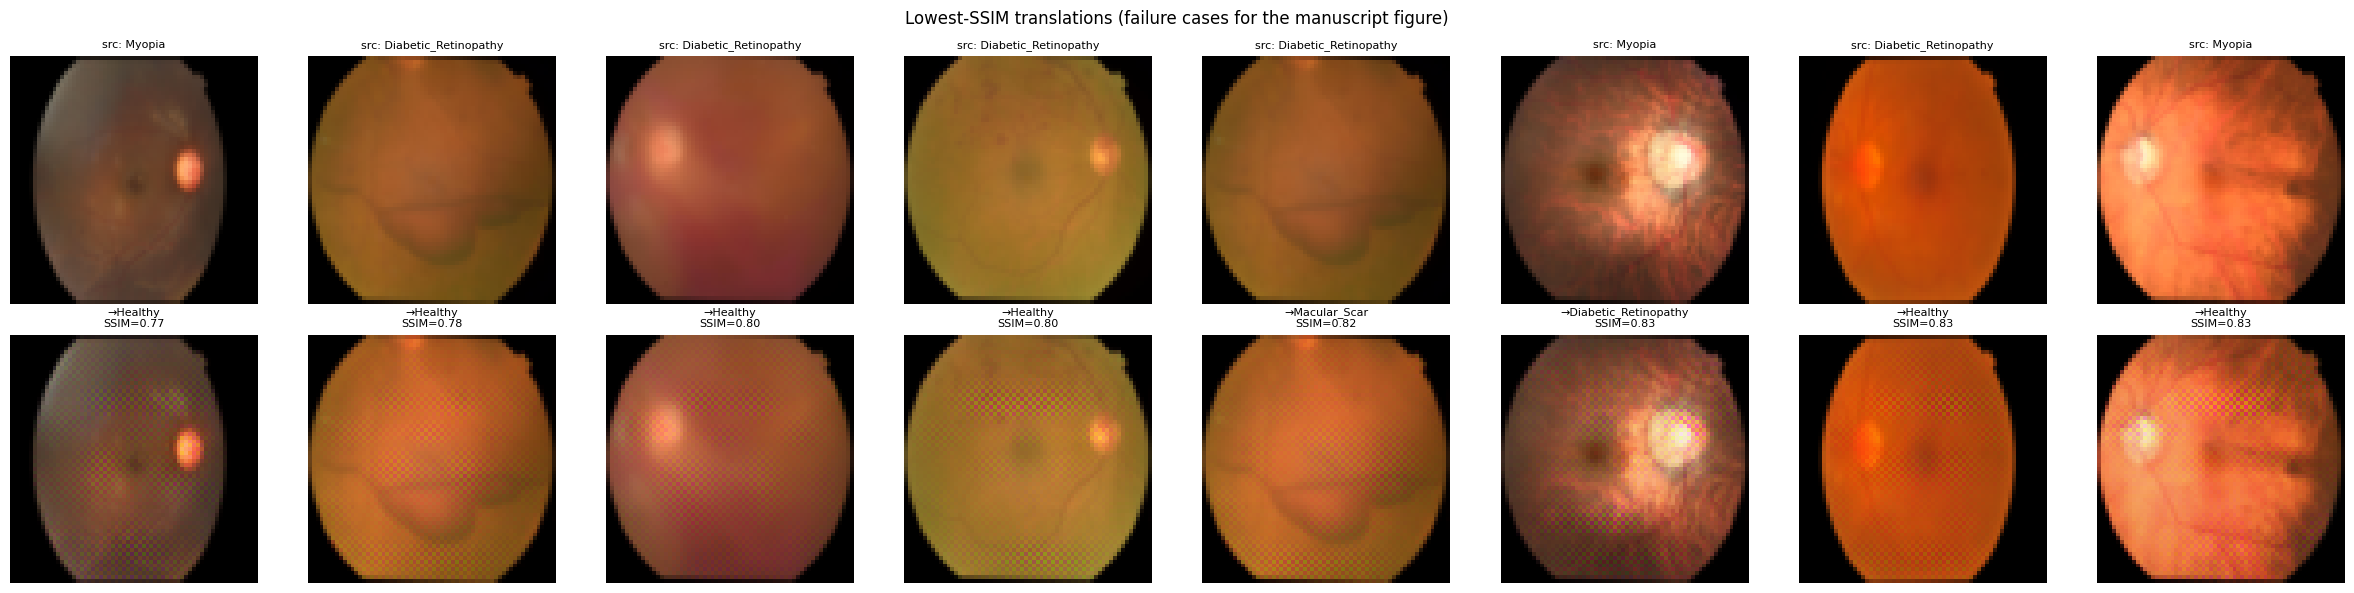

Saved: /content/drive/MyDrive/CSE720/revision/evaluation/failure_cases_grid.png


In [ ]:
worst = df.nsmallest(8, 'ssim')
print(worst[['image', 'source', 'target', 'psnr', 'ssim', 'mse']])

import torch.serialization
torch.serialization.add_safe_globals([Config])
ckpt = torch.load(os.path.join(cfg.checkpoint_dir, 'final_model.pth'), map_location=device, weights_only=False)
G = Generator(cfg.img_size, num_domains=cfg.num_domains).to(device)
G.load_state_dict(ckpt['G_state_dict']); G.eval()

test_dataset = MedicalDataset(cfg.dataset_path, cfg.img_size, 'test')
name_to_idx = {name: i for i, name in cfg.class_names.items()}
path_by_name = {os.path.basename(p): p for p in test_dataset.image_paths}

fig, axes = plt.subplots(2, len(worst), figsize=(3*len(worst), 6))
for col, (_, row) in enumerate(worst.iterrows()):
    img_path = path_by_name.get(row['image'])
    if img_path is None:
        continue
    from PIL import Image
    real_img = test_dataset.transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    target_idx = name_to_idx[row['target']]
    with torch.no_grad():
        fake = G(real_img, torch.tensor([target_idx], device=device))[0]
    real_np = np.clip((real_img[0].cpu()*0.5+0.5).numpy().transpose(1,2,0), 0, 1)
    fake_np = np.clip((fake.cpu()*0.5+0.5).numpy().transpose(1,2,0), 0, 1)
    axes[0, col].imshow(real_np); axes[0, col].set_title(f"src: {row['source']}", fontsize=8); axes[0, col].axis('off')
    axes[1, col].imshow(fake_np); axes[1, col].set_title(f"→{row['target']}\nSSIM={row['ssim']:.2f}", fontsize=8); axes[1, col].axis('off')
plt.suptitle('Lowest-SSIM translations (failure cases for the manuscript figure)')
plt.tight_layout()
fig_path = os.path.join(cfg.eval_dir, 'failure_cases_grid.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", fig_path)

In [ ]:
from metrics import FIDCalculator

fid_calc = FIDCalculator(device)
domain_diversity = {}

for target_domain, target_name in cfg.class_names.items():
    idxs = [i for i in range(len(test_dataset)) if test_dataset.labels[i] != target_domain][:40]  # cap for speed
    fakes = []
    with torch.no_grad():
        for i in idxs:
            real_img, _, _ = test_dataset[i]
            real_img = real_img.unsqueeze(0).to(device)
            fake = G(real_img, torch.tensor([target_domain], device=device))[0]
            fakes.append(fake.cpu())
    fakes = torch.stack(fakes)
    acts = fid_calc.get_activations(fakes)
    pairwise_dists = []
    for i in range(len(acts)):
        for j in range(i+1, len(acts)):
            pairwise_dists.append(np.linalg.norm(acts[i]-acts[j]))
    domain_diversity[target_name] = {
        'pixel_std_across_sources': fakes.std(dim=0).mean().item(),
        'mean_pairwise_feature_distance': float(np.mean(pairwise_dists)),
    }

div_df = pd.DataFrame(domain_diversity).T
print(div_df)
div_df.to_csv(os.path.join(cfg.eval_dir, 'diversity_mode_collapse_check.csv'))
print("\nLow mean_pairwise_feature_distance relative to other domains flags a possible "
      "mode-collapse tendency for that target class — report this table alongside the "
      "failure-case grid above in the response to R2-Q3a.")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 188MB/s] 
